# PROBLEM STATEMENT

---
---
Predict student performance based on study habits, attendance, and participation.
Also evaluate performance.

In [32]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [33]:
# mount drive to connect dataset
# load dataset
df = pd.read_csv('/content/drive/MyDrive/Tech Journey/datasets/student_performance.csv')
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [34]:
# data preprocessing

# check if any missing values
df.isnull().sum()

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0


there is no missing value in this dataset, so we can move further without handling missing values

In [35]:
# encoding categorical values - GRADE
# will perform one-hot encoding on feature GRADE
# df = pd.get_dummies(df['grade'], columns=['grade'], dtype=int)
# df.head()

In [36]:
# train test split data
x = df[['weekly_self_study_hours','attendance_percentage','class_participation']] # i/p - 2D
y = df[['total_score']] # o/p - 1D (now only numerical total_score) --> further encoded grade
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [37]:
# train model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [38]:
# make predictions
y_pred = model.predict(x_test)

In [39]:
# evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

Mean Absolute Error (MAE): 7.16
Mean Squared Error (MSE): 80.94
Root Mean Squared Error (RMSE): 9.00
R-squared (R2): 0.66


### Insight:
- as per r² score, accuracy of model is more better than an avg model

### Visualizing the impact of each input feature on Total Score

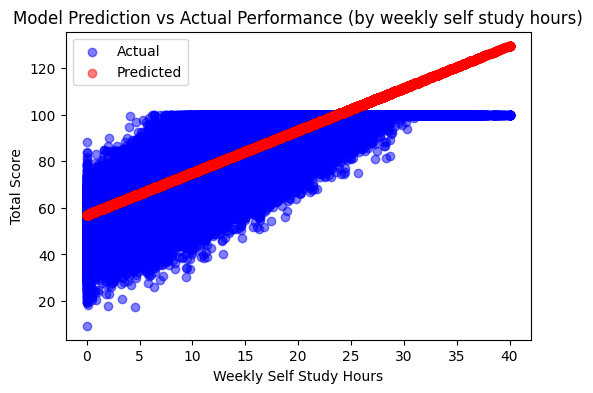

In [57]:
# Plotting weekly self study hours vs Total Score
plt.figure(figsize=(6,4))
plt.scatter(x_test['weekly_self_study_hours'], y_test, color='blue', label='Actual', alpha=0.5)
plt.scatter(x_test['weekly_self_study_hours'], y_pred, color='red', label='Predicted', alpha=0.5)
plt.xlabel('Weekly Self Study Hours')
plt.ylabel('Total Score')
plt.title('Model Prediction vs Actual Performance (by weekly self study hours)')
plt.legend()
plt.savefig('study_hours.png')
plt.show()

### Insight:

- There is a strong positive linear relationship between weekly self-study hours and total score.

- As study hours increase, the student’s score consistently increases.

- The model prediction line closely follows the actual data points, indicating that study hours are a strong predictor of performance.

**Conclusion**: Self-study hours is the most influential feature in determining student performance.

/tmp/ipykernel_4751/3608554801.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('attendance.png')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


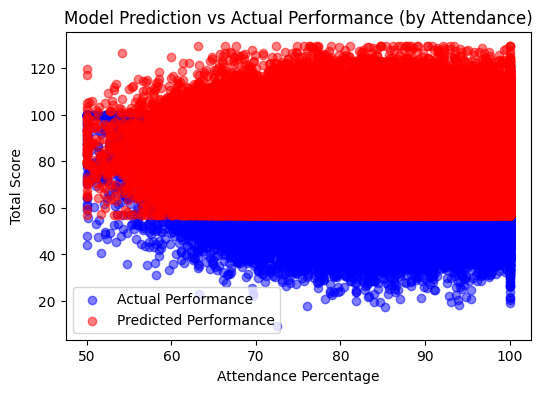

In [58]:
# Plotting Attendance Percentage vs Total Score
plt.figure(figsize=(6,4))
plt.scatter(x_test['attendance_percentage'], y_test, color='blue', label='Actual Performance', alpha=0.5)
plt.scatter(x_test['attendance_percentage'], y_pred, color='red', label='Predicted Performance', alpha=0.5)
plt.xlabel('Attendance Percentage')
plt.ylabel('Total Score')
plt.title('Model Prediction vs Actual Performance (by Attendance)')
plt.legend()
plt.savefig('attendance.png')
plt.show()

### Insight:

- The relationship between attendance and total score is weaker compared to study hours.

- Although higher attendance slightly improves performance, the data points are widely scattered, indicating low correlation.

- The model struggles to capture a clear pattern here.

**Conclusion**: Attendance alone is not a strong predictor of student performance.

/tmp/ipykernel_4751/2564707426.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('participation.png')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


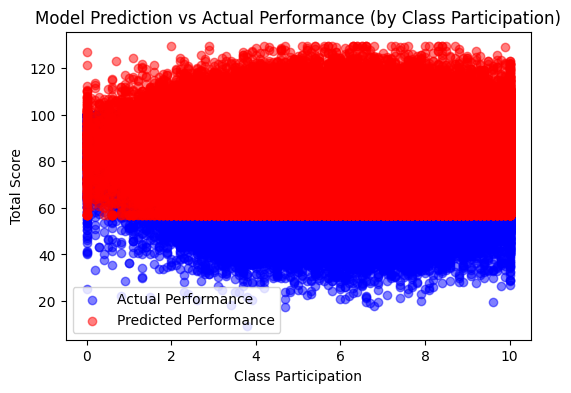

In [59]:
# Plotting Class Participation vs Total Score
plt.figure(figsize=(6,4))
plt.scatter(x_test['class_participation'], y_test, color='blue', label='Actual Performance', alpha=0.5)
plt.scatter(x_test['class_participation'], y_pred, color='red', label='Predicted Performance', alpha=0.5)
plt.xlabel('Class Participation')
plt.ylabel('Total Score')
plt.title('Model Prediction vs Actual Performance (by Class Participation)')
plt.legend()
plt.savefig('participation.png')
plt.show()

### Insight:

- Class participation shows a moderate relationship with total score.

- There is a slight upward trend, but the spread of data indicates variability in performance.

- Students with similar participation levels can have significantly different scores.

**Conclusion**: Class participation contributes to performance but is less impactful than study hours.

## Overall Conclusion:

- Among all features, weekly self-study hours has the strongest impact on student performance.

- Attendance and class participation have relatively weaker influence and do not show strong predictive patterns individually.

This suggests that consistent self-study is the key driver of academic success in this dataset.

In [56]:
# optional - prediction based on user i/p
hrs = float(input('enter your weekly studied hrs: '))
atnd = float(input('enter your attendance percentage: '))
part = float(input('enter your class participation: '))

res = model.predict(pd.DataFrame([[hrs, atnd, part]], columns = ['weekly_self_study_hours','attendance_percentage','class_participation']))[0] # to avoid structural warnings
# res = model.predict([[hrs, atnd, part]])[0]

print(f'As per ur hrs {hrs}, attendance {atnd}, and class participation {part} you may score : {res}')

enter your weekly studied hrs: 20.37
enter your attendance percentage: 89.10
enter your class participation: 6.4
As per ur hrs 20.37, attendance 89.1, and class participation 6.4 you may score : [93.98034142]
